# Explore Activations
Compare activation statistics across multiple runs. Visualize activations for a chosen episode/timestep.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [4]:
# ── Configure runs here ──
# Map label -> path to all_episodes.pkl (or trajectory folder containing it)
RUNS = {
    'no reg': '../logdir/ego_fs_true_envmods/trajectories/all_episodes.pkl',
    'L1 1e-1; wd 1e-1': '../logdir/ego_sweep_l11e-1_wd1e-1/trajectories/all_episodes.pkl',
    'L1 1e0; wd 1e-1': '../logdir/ego_sweep_l11e0_wd1e-1/trajectories/all_episodes.pkl',
    'L1 1e1; wd 1e-1': '../logdir/ego_sweep_l11e1_wd1e-1/trajectories/all_episodes.pkl',
    'L1 1e-1; wd 1e0': '../logdir/ego_sweep_l11e-1_wd1e0/trajectories/all_episodes.pkl',
    'L1 1e0; wd 1e0': '../logdir/ego_sweep_l11e0_wd1e0/trajectories/all_episodes.pkl',
    'L1 1e1; wd 1e0': '../logdir/ego_sweep_l11e1_wd1e0/trajectories/all_episodes.pkl'
}
MAX_EPISODES = 10  # limit to first N episodes per run (None = all)

# Load all runs
runs = {}
for label, path in RUNS.items():
    p = Path(path)
    if p.is_dir():
        p = p / 'all_episodes.pkl'
    with open(p, 'rb') as f:
        data = pickle.load(f)
    if MAX_EPISODES is not None:
        data['episodes'] = data['episodes'][:MAX_EPISODES]
    runs[label] = data
    print(f"[{label}] {len(runs[label]['episodes'])} episodes from {p}")

# Discover act/* keys from first run
_ep0 = runs[list(runs.keys())[0]]['episodes'][0]
act_keys = sorted([k for k in _ep0.keys() if k.startswith('act/')])
print(f"\nActivation layers ({len(act_keys)}):")
for k in act_keys:
    print(f"  {k}  dim={np.array(_ep0[k]).shape[1]}")

[no reg] 10 episodes from ../logdir/ego_fs_true_envmods/trajectories/all_episodes.pkl
[L1 1e-1; wd 1e-1] 10 episodes from ../logdir/ego_sweep_l11e-1_wd1e-1/trajectories/all_episodes.pkl
[L1 1e0; wd 1e-1] 10 episodes from ../logdir/ego_sweep_l11e0_wd1e-1/trajectories/all_episodes.pkl
[L1 1e1; wd 1e-1] 10 episodes from ../logdir/ego_sweep_l11e1_wd1e-1/trajectories/all_episodes.pkl
[L1 1e-1; wd 1e0] 10 episodes from ../logdir/ego_sweep_l11e-1_wd1e0/trajectories/all_episodes.pkl
[L1 1e0; wd 1e0] 10 episodes from ../logdir/ego_sweep_l11e0_wd1e0/trajectories/all_episodes.pkl
[L1 1e1; wd 1e0] 10 episodes from ../logdir/ego_sweep_l11e1_wd1e0/trajectories/all_episodes.pkl

Activation layers (13):
  act/dyn/deter  dim=3072
  act/dyn/stoch  dim=768
  act/enc/cnn0  dim=49152
  act/enc/cnn1  dim=18432
  act/enc/cnn2  dim=6144
  act/enc/cnn3  dim=1536
  act/enc/tokens  dim=1536
  act/pol/mlp/linear0  dim=384
  act/pol/mlp/linear1  dim=384
  act/pol/mlp/linear2  dim=384
  act/val/mlp/linear0  dim=384

In [5]:
# ── Stats table: all runs x all layers ──
# Concatenates all episodes per run to get global stats per layer.

def layer_stats(episodes, layer_key):
    """Compute stats for one layer across all episodes."""
    all_v = []
    for ep in episodes:
        if layer_key in ep:
            all_v.append(np.array(ep[layer_key], dtype=np.float32))
    if not all_v:
        return None
    v = np.concatenate(all_v)  # (total_timesteps, D)
    flat = v.ravel()
    return {
        'dim': v.shape[1],
        'mean': np.mean(flat),
        'median': np.median(flat),
        'min': np.min(flat),
        'max': np.max(flat),
        'std': np.std(flat),
        'frac_neg': np.mean(flat < 0),
        'frac_zero': np.mean(flat == 0),
        'sparsity(|x|<0.01)': np.mean(np.abs(flat) < 0.01),
        'active_neurons(mean|x|>0.01)': int(np.sum(np.mean(np.abs(v), axis=0) > 0.01)),
        'neurons_w_neg': int(np.sum(np.any(v < 0, axis=0))),
    }

rows = []
for label, data in runs.items():
    for k in act_keys:
        s = layer_stats(data['episodes'], k)
        if s is None:
            continue
        s['run'] = label
        s['layer'] = k.replace('act/', '')
        rows.append(s)

df = pd.DataFrame(rows)
col_order = ['layer', 'run', 'dim', 'mean', 'median', 'min', 'max', 'std',
             'frac_neg', 'frac_zero', 'sparsity(|x|<0.01)', 'active_neurons(mean|x|>0.01)', 'neurons_w_neg']
df = df[col_order]

# Sort by layer order, then run
layer_order = [k.replace('act/', '') for k in act_keys]
df['_layer_idx'] = df['layer'].map({ln: i for i, ln in enumerate(layer_order)})
df = df.sort_values(['_layer_idx', 'run']).drop(columns='_layer_idx').reset_index(drop=True)

# Format for display
fmt = df.copy()
for c in ['mean', 'median', 'min', 'max', 'std']:
    fmt[c] = fmt[c].map(lambda x: f'{x:.4f}')
for c in ['frac_neg', 'frac_zero', 'sparsity(|x|<0.01)']:
    fmt[c] = fmt[c].map(lambda x: f'{x:.1%}')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
display(fmt)

,layer,run,dim,mean,median,min,max,std,frac_neg,frac_zero,sparsity(|x|<0.01),active_neurons(mean|x|>0.01),neurons_w_neg
0,dyn/deter,L1 1e-1; wd 1e-1,3072,0.0681,0.0024,0.0000,13.4375,0.2332,0.0%,9.8%,59.3%,2651,0
1,dyn/deter,L1 1e-1; wd 1e0,3072,0.0105,0.0000,0.0000,1.1953,0.0430,0.0%,32.9%,85.9%,752,0
2,dyn/deter,L1 1e0; wd 1e-1,3072,0.0577,0.0015,0.0000,8.3750,0.2087,0.0%,10.7%,62.2%,2521,0
3,dyn/deter,L1 1e0; wd 1e0,3072,0.0086,0.0000,0.0000,0.9844,0.0368,0.0%,36.8%,87.6%,675,0
4,dyn/deter,L1 1e1; wd 1e-1,3072,0.0227,0.0000,0.0000,3.9062,0.0868,0.0%,20.1%,76.7%,1450,0
5,dyn/deter,L1 1e1; wd 1e0,3072,0.0076,0.0000,0.0000,1.0703,0.0344,0.0%,36.8%,89.2%,542,0
6,dyn/deter,no reg,3072,0.2084,0.0105,0.0000,19.2500,0.6896,0.0%,13.2%,49.7%,2799,0
7,dyn/stoch,L1 1e-1; wd 1e-1,768,0.0417,0.0000,0.0000,1.0000,0.1998,0.0%,95.8%,95.8%,321,0
8,dyn/stoch,L1 1e-1; wd 1e0,768,0.0417,0.0000,0.0000,1.0000,0.1998,0.0%,95.8%,95.8%,245,0
9,dyn/stoch,L1 1e0; wd 1e-1,768,0.0417,0.0000,0.0000,1.0000,0.1998,0.0%,95.8%,95.8%,288,0


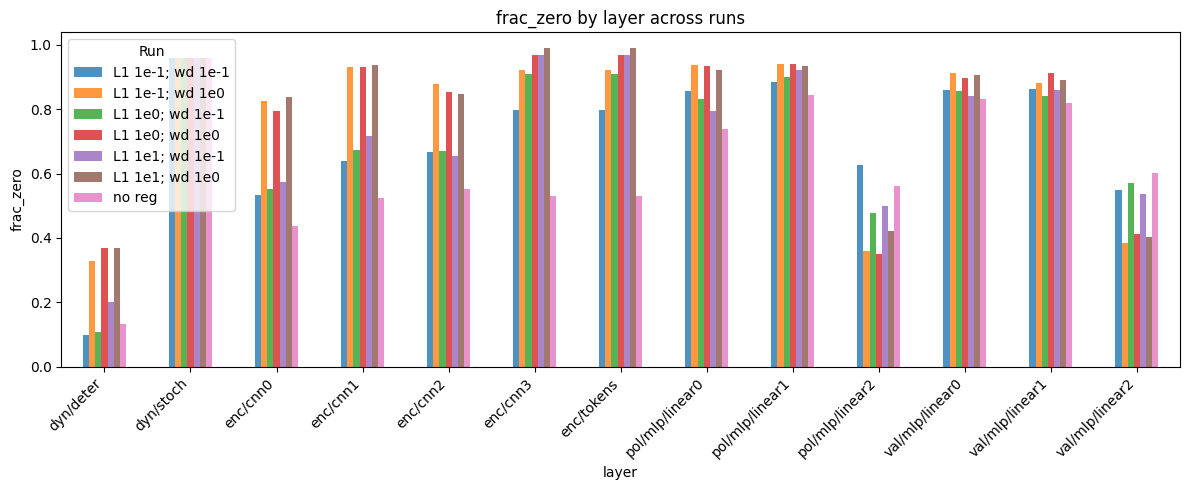

In [7]:
# ── Compare a chosen metric across runs (bar chart per layer) ──
METRIC = 'frac_zero'  # change to: mean, median, frac_neg, frac_zero, sparsity(<0.01), std, etc.

pivot = df.pivot(index='layer', columns='run', values=METRIC)
# Reorder layers
pivot = pivot.reindex([k.replace('act/', '') for k in act_keys])

fig, ax = plt.subplots(figsize=(12, 5))
pivot.plot.bar(ax=ax, alpha=0.8)
ax.set_ylabel(METRIC)
ax.set_title(f'{METRIC} by layer across runs')
ax.legend(title='Run')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

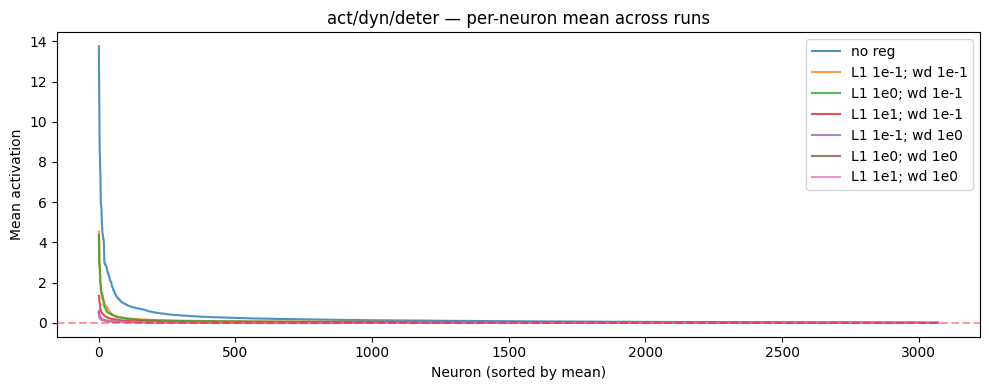

In [8]:
# ── Per-neuron sorted mean activation curve (all runs overlaid) ──
LAYER = 'act/dyn/deter'  # change as needed

fig, ax = plt.subplots(figsize=(10, 4))
for label, data in runs.items():
    all_v = np.concatenate([np.array(ep[LAYER], dtype=np.float32) for ep in data['episodes']])
    neuron_mean = np.mean(all_v, axis=0)
    ax.plot(np.sort(neuron_mean)[::-1], label=label, alpha=0.8)

ax.axhline(0, color='red', linestyle='--', alpha=0.4)
ax.set_xlabel('Neuron (sorted by mean)')
ax.set_ylabel('Mean activation')
ax.set_title(f'{LAYER} — per-neuron mean across runs')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2306529/2258523848.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False,


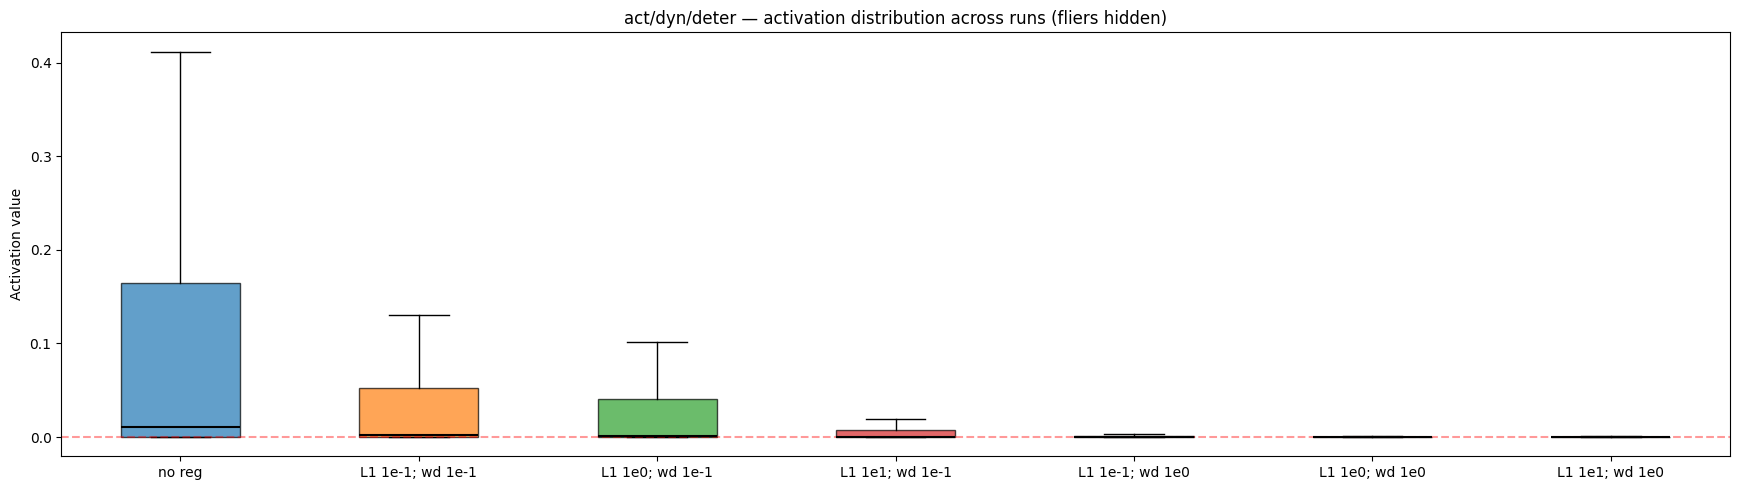

  no reg                1%=0.0000  Q1=0.0000  median=0.0106  Q3=0.1650  99%=2.8281  frac_neg=0.0%
  L1 1e-1; wd 1e-1      1%=0.0000  Q1=0.0000  median=0.0024  Q3=0.0527  99%=0.8360  frac_neg=0.0%
  L1 1e0; wd 1e-1       1%=0.0000  Q1=0.0000  median=0.0015  Q3=0.0408  99%=0.7539  frac_neg=0.0%
  L1 1e1; wd 1e-1       1%=0.0000  Q1=0.0000  median=0.0000  Q3=0.0076  99%=0.3848  frac_neg=0.0%
  L1 1e-1; wd 1e0       1%=0.0000  Q1=0.0000  median=0.0000  Q3=0.0011  99%=0.2031  frac_neg=0.0%
  L1 1e0; wd 1e0        1%=0.0000  Q1=0.0000  median=0.0000  Q3=0.0004  99%=0.1699  frac_neg=0.0%
  L1 1e1; wd 1e0        1%=0.0000  Q1=0.0000  median=0.0000  Q3=0.0003  99%=0.1660  frac_neg=0.0%


In [9]:
# ── Boxplots: activation distributions per run for chosen layer ──
LAYER = 'act/dyn/deter'

run_labels = list(runs.keys())
box_data = []
box_labels = []
for label in run_labels:
    flat = np.concatenate([np.array(ep[LAYER], dtype=np.float32).ravel()
                           for ep in runs[label]['episodes']])
    # Subsample if huge (boxplot gets slow with millions of points)
    if len(flat) > 500_000:
        flat = np.random.default_rng(0).choice(flat, 500_000, replace=False)
    box_data.append(flat)
    box_labels.append(label)

fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(run_labels)), 5))
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showfliers=False,
                widths=0.5, medianprops=dict(color='black', linewidth=1.5))

colors = plt.cm.tab10.colors
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.7)

ax.axhline(0, color='red', linestyle='--', alpha=0.4)
ax.set_ylabel('Activation value')
ax.set_title(f'{LAYER} — activation distribution across runs (fliers hidden)')
plt.tight_layout()
plt.show()

# Print summary to complement the boxplot
for label, d in zip(box_labels, box_data):
    pcts = np.percentile(d, [1, 25, 50, 75, 99])
    print(f"  {label:20s}  1%={pcts[0]:.4f}  Q1={pcts[1]:.4f}  median={pcts[2]:.4f}  "
          f"Q3={pcts[3]:.4f}  99%={pcts[4]:.4f}  frac_neg={np.mean(d<0):.1%}")

In [ ]:
# ── Visualize activations for a specific episode + timestep ──
RUN = list(runs.keys())[0]  # pick run
EP_IDX = 0                   # episode index
TIMESTEP = 50                # timestep within episode
LAYER = 'act/dyn/deter'     # layer to visualize

ep = runs[RUN]['episodes'][EP_IDX]
act_vec = np.array(ep[LAYER], dtype=np.float32)[TIMESTEP]  # (D,)
print(f"Run={RUN}  ep={EP_IDX}  t={TIMESTEP}  layer={LAYER}  dim={len(act_vec)}")
print(f"  mean={act_vec.mean():.4f}  min={act_vec.min():.4f}  max={act_vec.max():.4f}  "
      f"frac_neg={np.mean(act_vec < 0):.1%}  frac_zero={np.mean(act_vec == 0):.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Bar plot of activation values
ax = axes[0]
ax.bar(range(len(act_vec)), act_vec, width=1.0, color=np.where(act_vec < 0, 'red', 'steelblue'), alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Neuron index')
ax.set_ylabel('Activation')
ax.set_title(f'Activations at t={TIMESTEP}')

# 2D reshape if possible (for spatial intuition)
ax = axes[1]
D = len(act_vec)
# Find a reasonable 2D shape
h = int(np.sqrt(D))
while D % h != 0 and h > 1:
    h -= 1
w = D // h
im = ax.imshow(act_vec.reshape(h, w), aspect='auto', interpolation='nearest', cmap='RdBu_r',
               vmin=-max(abs(act_vec.min()), act_vec.max()),
               vmax=max(abs(act_vec.min()), act_vec.max()))
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Reshaped {h}x{w}')

# Show the observation image at this timestep
ax = axes[2]
if 'image' in ep:
    img = np.array(ep['image'])[TIMESTEP]
    ax.imshow(img)
    ax.set_title(f'Observation at t={TIMESTEP}')
else:
    ax.text(0.5, 0.5, 'No image data', ha='center', va='center', transform=ax.transAxes)
ax.axis('off')

fig.suptitle(f'{RUN} — ep {EP_IDX}, t={TIMESTEP}, {LAYER}', fontsize=11)
plt.tight_layout()
plt.show()